# Phase 2: YOLOv8n Training Notebook — Diagram-to-Infra-Code

This notebook trains a custom **YOLOv8n** object detection model on synthetic architecture diagram data.

### Target Classes (7 total):
1. `compute` (EC2, EKS)
2. `database` (RDS)
3. `storage` (S3)
4. `load_balancer` (ALB)
5. `network` (VPC/Subnet boundary)
6. `arrow` (directional connection)
7. `text_label` (label box text)

Run this notebook on Google Colab with GPU acceleration enabled (**Runtime -> Change runtime type -> T4 GPU**).

## Setup & Resume Instructions

**If you disconnect during training:**
1. Re-run Steps 1, 2, and 3 to setup the environment and dataset.
2. **Skip Step 4 (Original Training Cell)**.
3. **Run Step 4b (Resume Cell)** to continue training from your Google Drive checkpoint.

## Step 1: GPU Check, Environment Setup & Mount Drive
We mount Google Drive so checkpoints survive runtime disconnects.

In [ ]:
!nvidia-smi
!pip install -q ultralytics huggingface_hub opencv-python-headless albumentations pillow

from google.colab import drive
drive.mount('/content/drive')

Mon Sep  7 06:29:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2: Clone Repository

In [ ]:
!git clone https://github.com/Parths-29/Diagram-to-Infra-code.git
%cd Diagram-to-Infra-code

Cloning into 'Diagram-to-Infra-code'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 114 (delta 32), reused 92 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (114/114), 93.40 KiB | 783.00 KiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/Diagram-to-Infra-code


## Step 3: Generate Dataset

In [ ]:
# Generate 500 unique diagrams + 1 copy = 1,000 total images
!python3 data/generate_synthetic.py --output data/synthetic_dataset --count 500 --augmented-copies 1 --seed 42

Generating synthetic dataset:
  Output: data/synthetic_dataset
  Count: 500 unique diagrams
  Augmented copies: 1 per image
  Seed: 42

  Generated 50/500 diagrams (100 total with augmentations)...
  Generated 100/500 diagrams (200 total with augmentations)...
  Generated 150/500 diagrams (300 total with augmentations)...
  Generated 200/500 diagrams (400 total with augmentations)...
  Generated 250/500 diagrams (500 total with augmentations)...
  Generated 300/500 diagrams (600 total with augmentations)...
  Generated 350/500 diagrams (700 total with augmentations)...
  Generated 400/500 diagrams (800 total with augmentations)...
  Generated 450/500 diagrams (900 total with augmentations)...
  Generated 500/500 diagrams (1000 total with augmentations)...

Dataset generation complete!
  Unique diagrams: 500
  Total images (with augmentations): 1000
  Train: data/synthetic_dataset/train/
  Val:   data/synthetic_dataset/val/


## Step 4: Run YOLOv8n Training (Original Run)

Explicit augmentation kwargs:
- `fliplr=0.0` and `flipud=0.0` (disabled horizontal/vertical flips to preserve text & arrow orientation)
- `degrees=10.0`, `translate=0.1`, `scale=0.2`, `mosaic=0.5`, `mixup=0.1`

**Checkpoints are saved to Google Drive:** `/content/drive/MyDrive/diagram-to-infra-runs`

In [ ]:
from ultralytics import YOLO
import sys
sys.path.append('.')
from ml.train import generate_eval_samples

model = YOLO("yolov8n.pt")
results = model.train(
    data="data/dataset.yaml",
    epochs=50,
    batch=16,
    imgsz=640,
    project="/content/drive/MyDrive/diagram-to-infra-runs",
    name="train",
    patience=10,
    degrees=10.0,
    translate=0.1,
    scale=0.2,
    mosaic=0.5,
    mixup=0.1,
    fliplr=0.0,
    flipud=0.0
)

# Capture the dynamic run directory (e.g., train, train2, train3)
run_dir = results.save_dir
print(f"\nTraining completed. Results saved to: {run_dir}")

generate_eval_samples(model, "data/synthetic_dataset/val/images", "ml/eval_samples", num_samples=15)


Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/dataset.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False, optim

## Step 4b: Resume Training (Use if Disconnected)
If Colab disconnected, uncomment and run this cell *instead* of Step 4 above to resume from your last checkpoint.

In [ ]:
# from ultralytics import YOLO
# YOLO('/content/drive/MyDrive/diagram-to-infra-runs/train/weights/last.pt').train(resume=True)

## Step 5: Display Training Results & Visual Evaluation Samples

=== Training Confusion Matrix ===


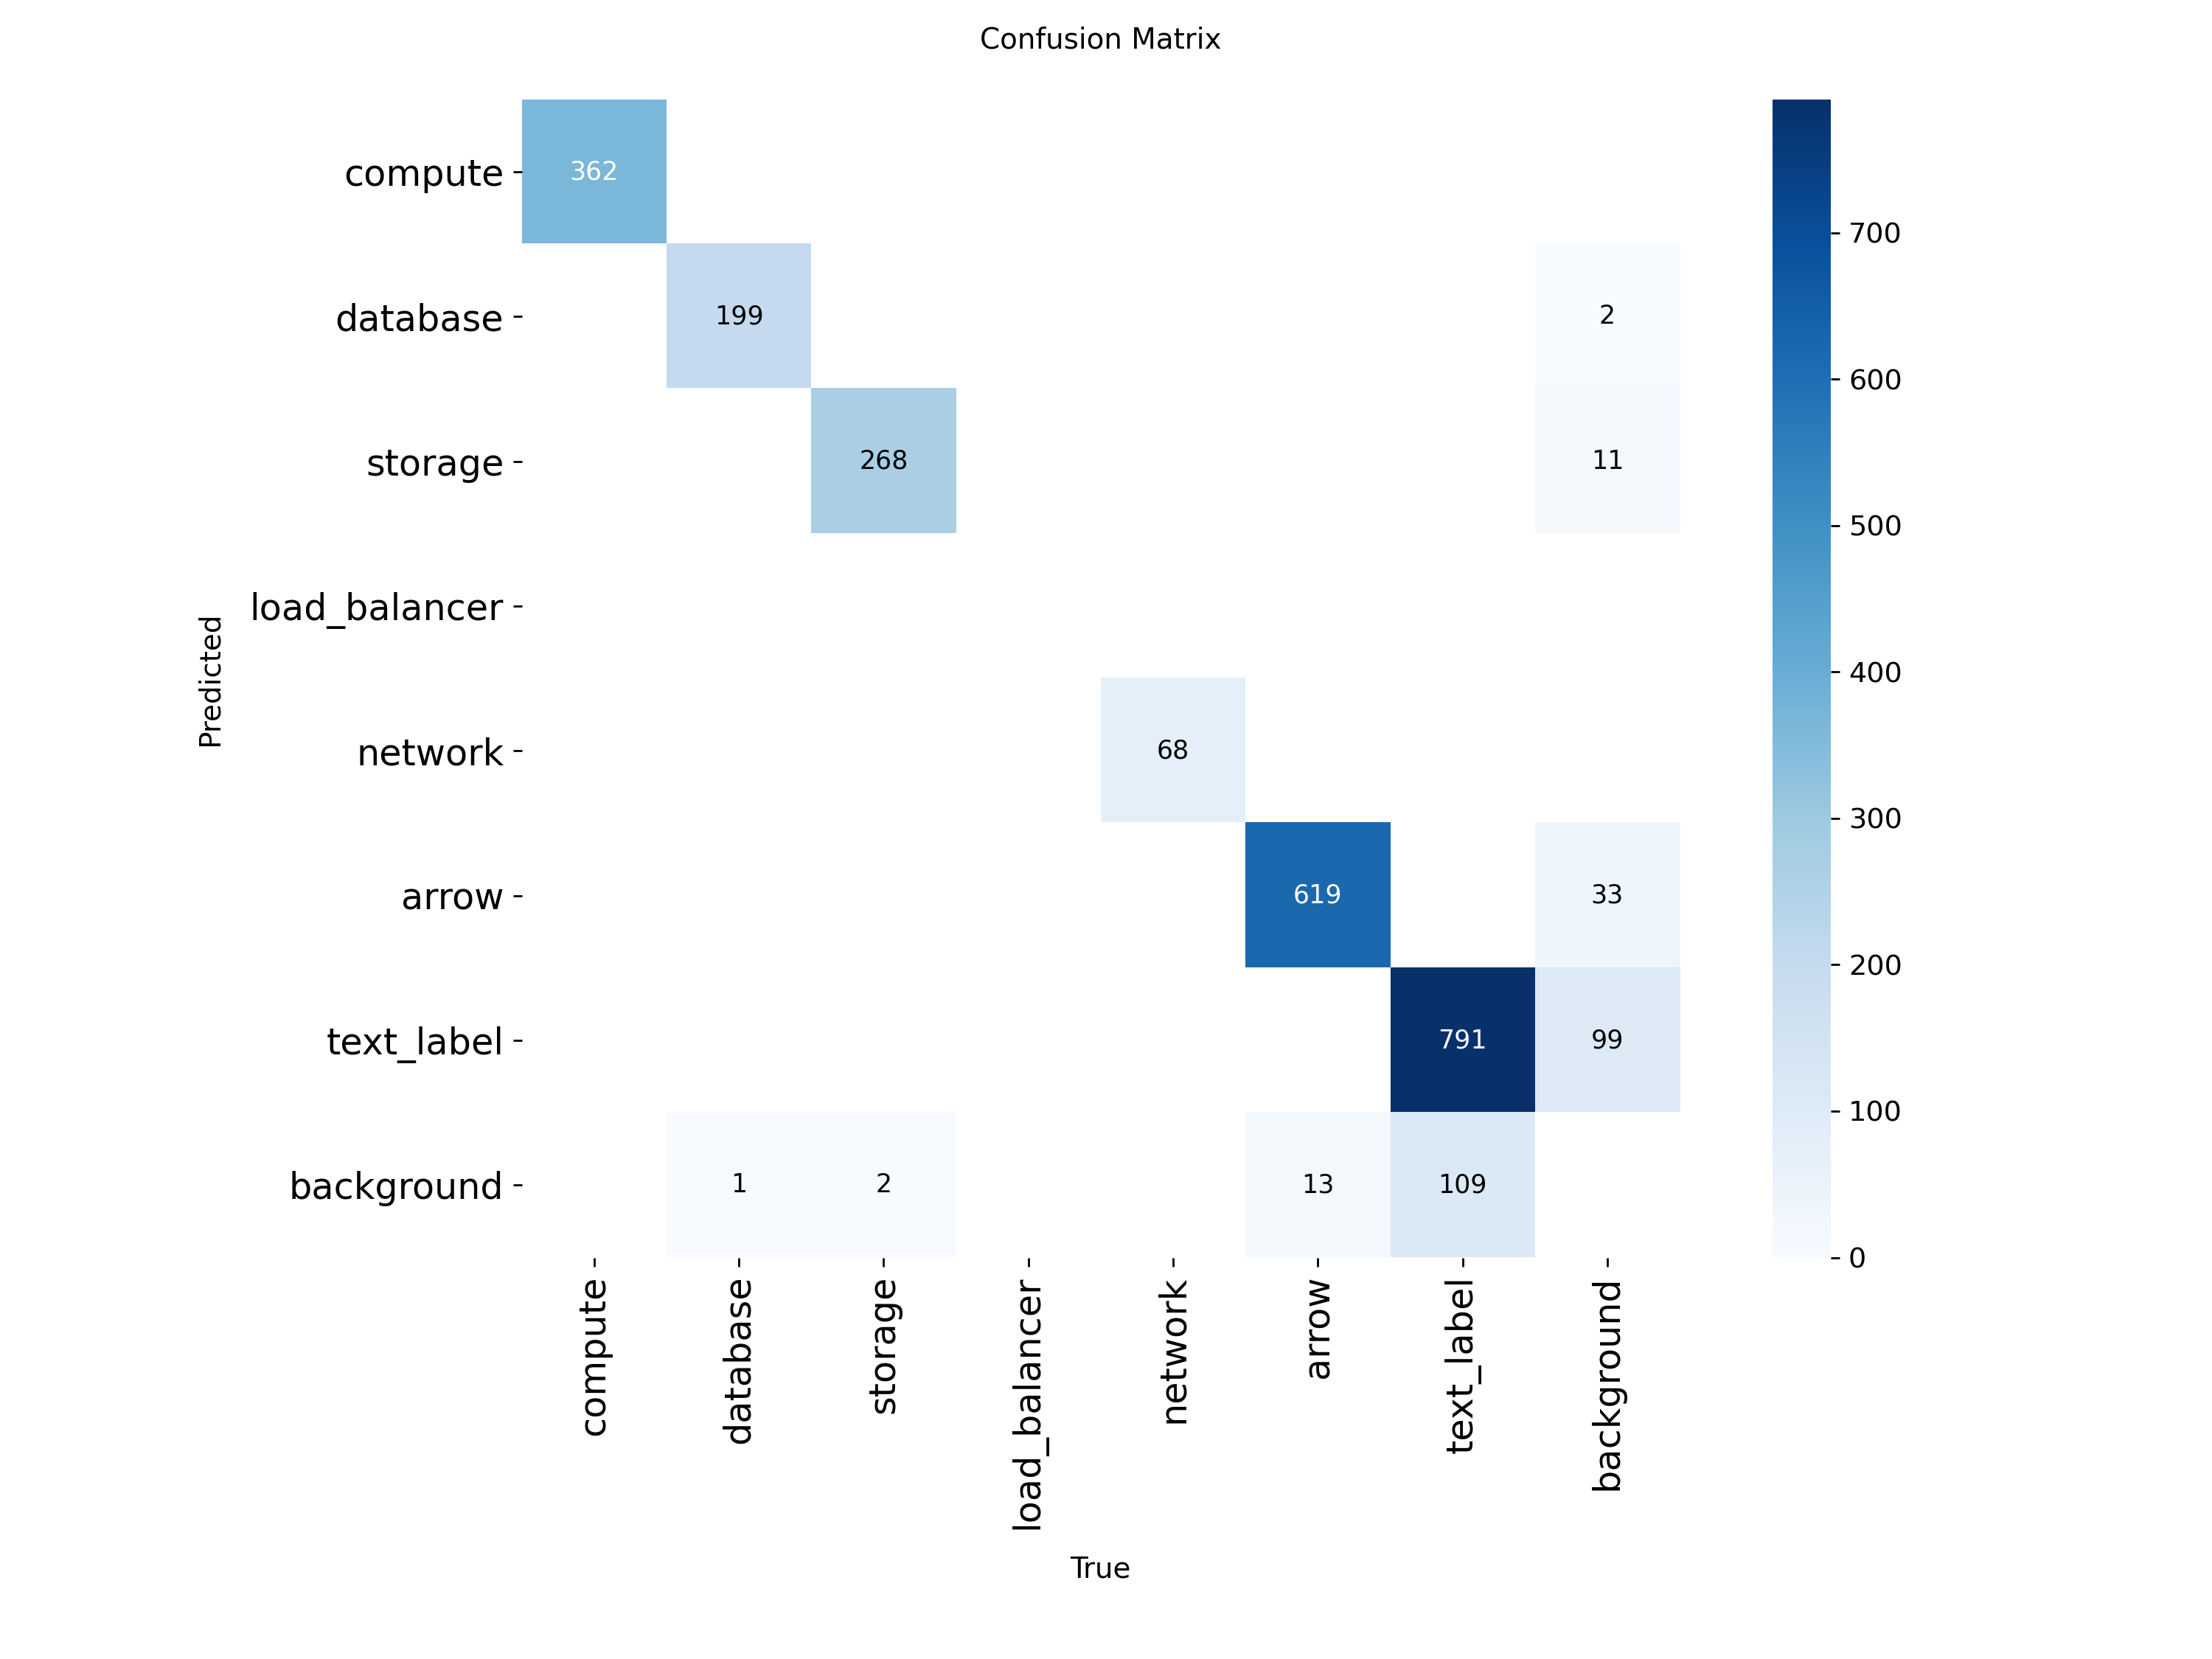

=== Results Curves ===


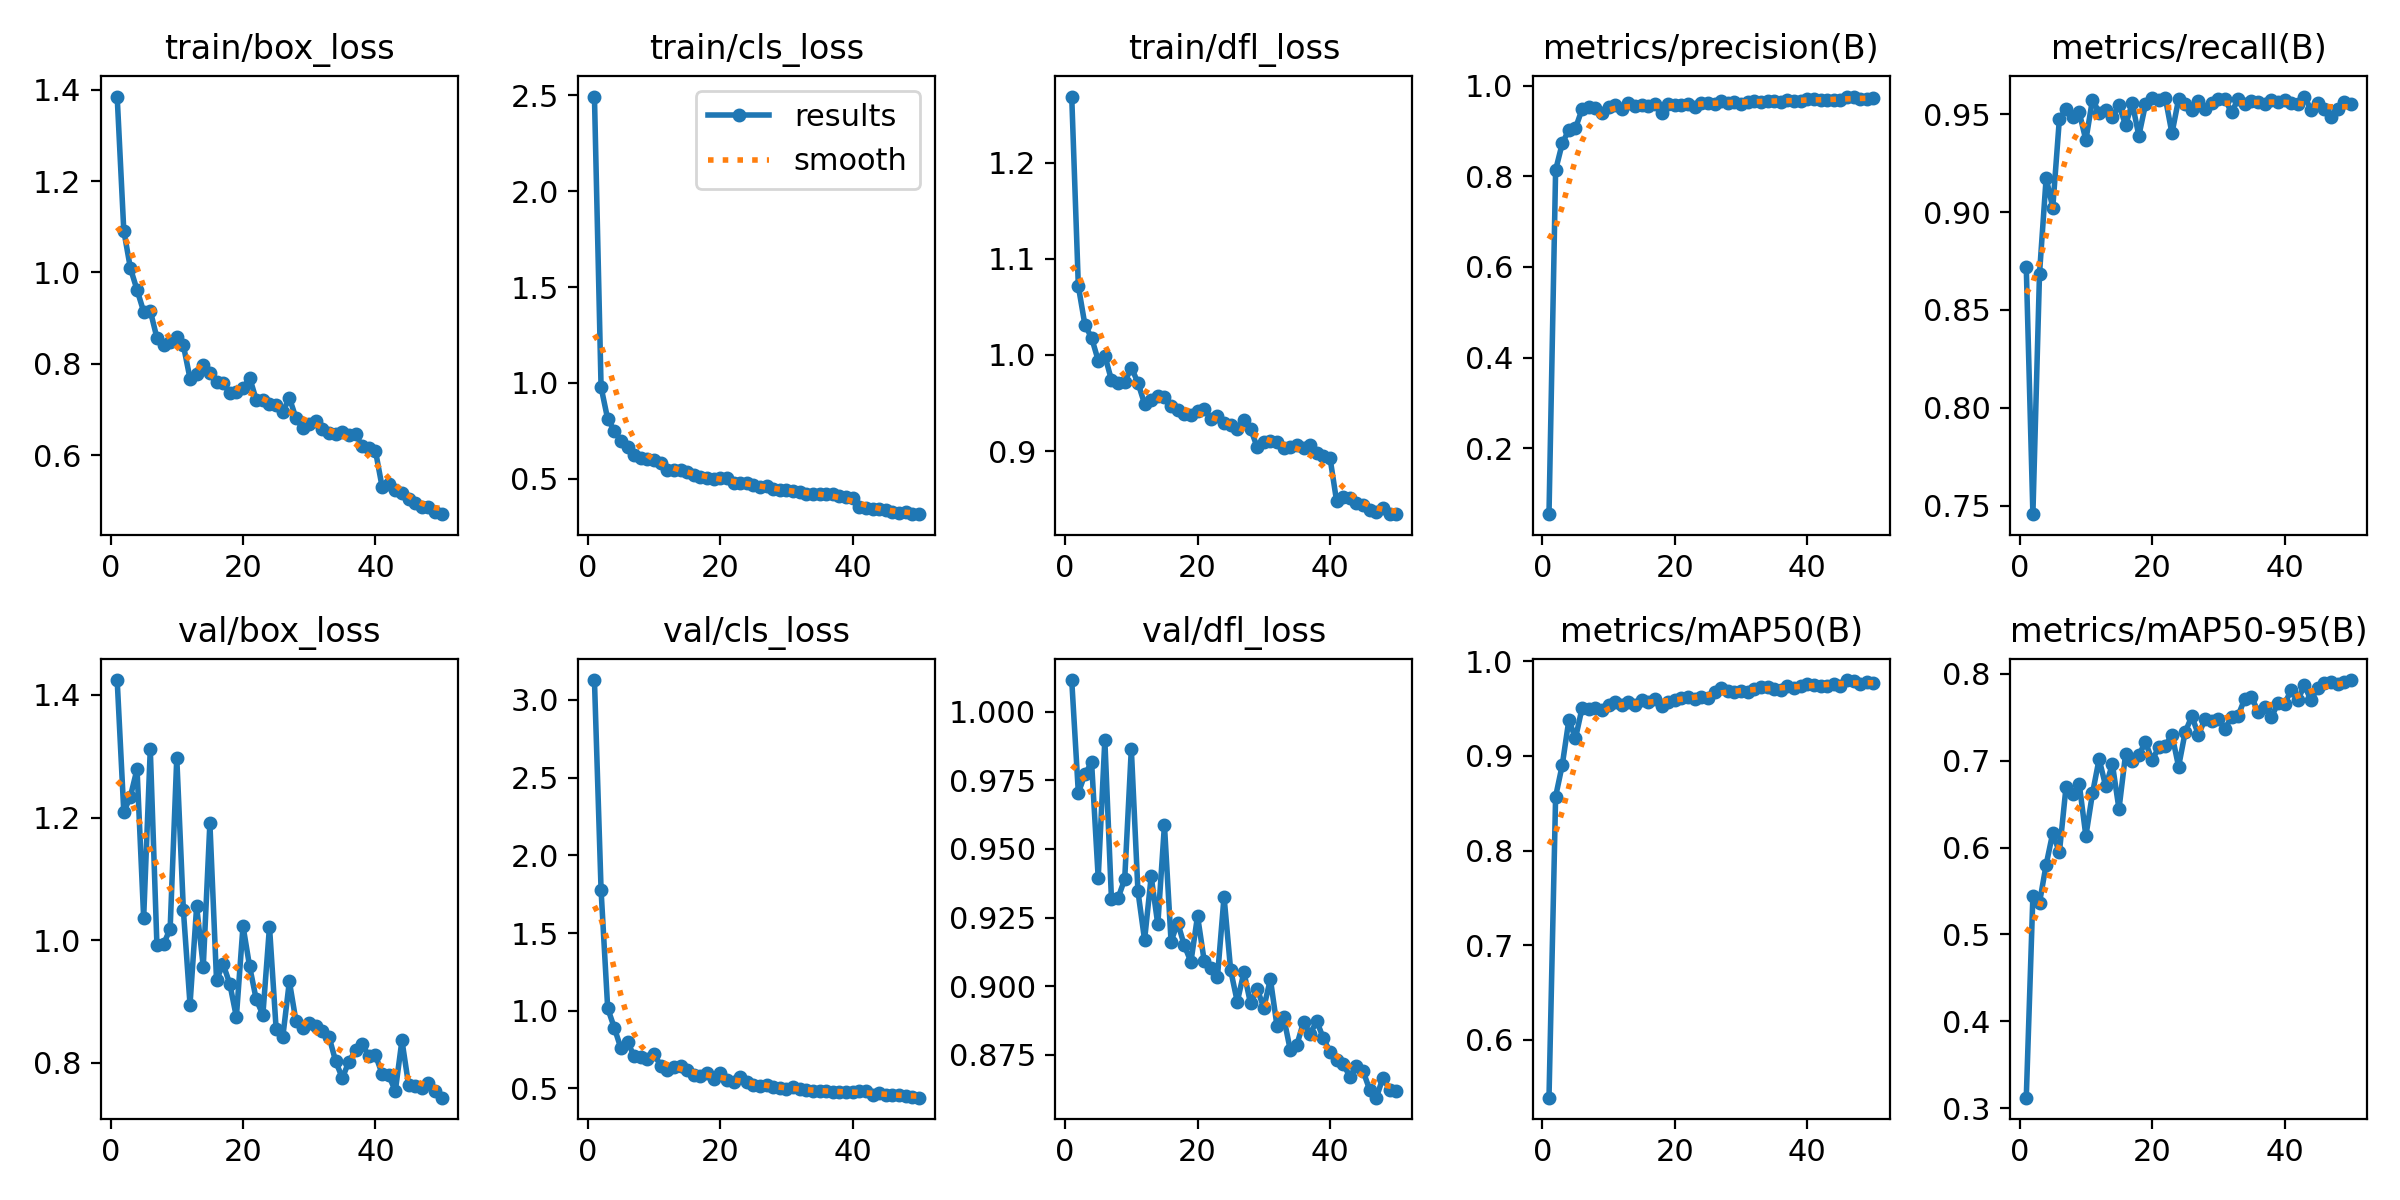

=== Sample Visual Predictions (from ml/eval_samples/) ===


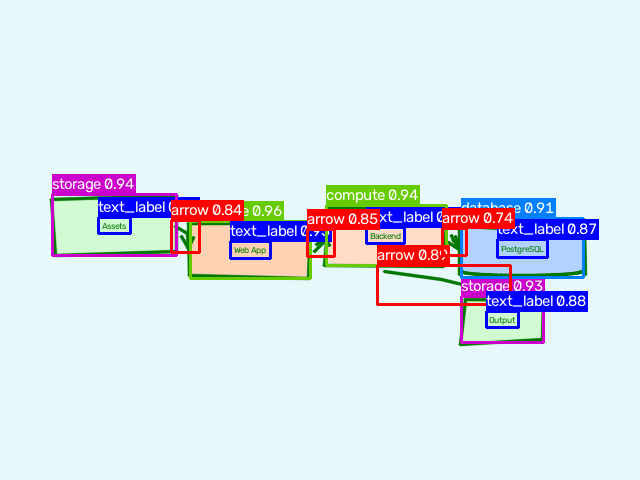

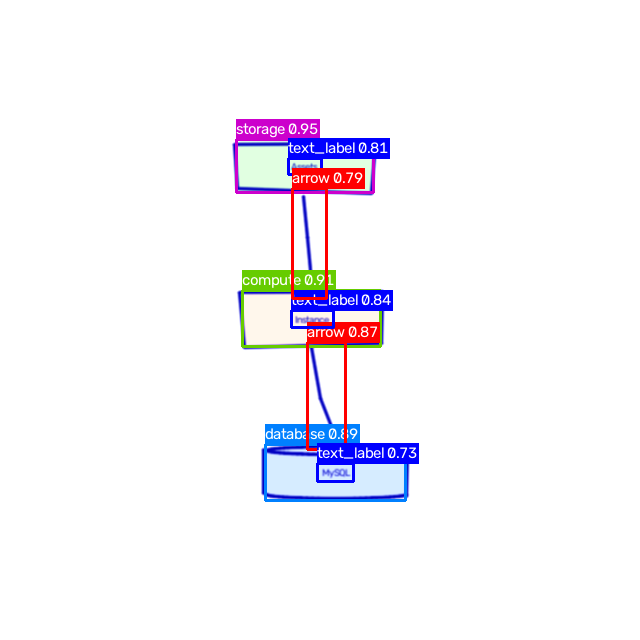

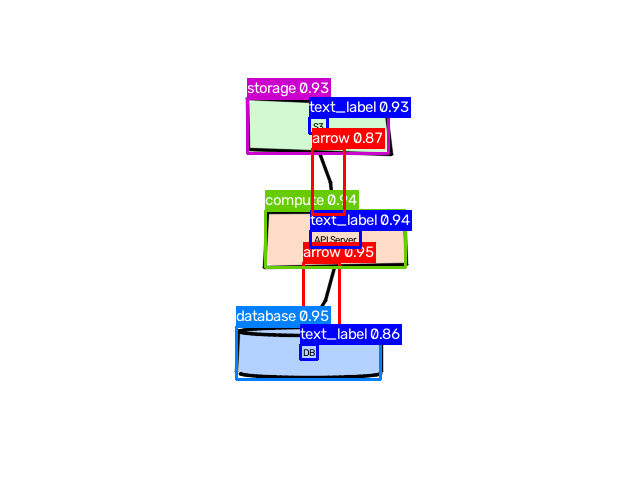

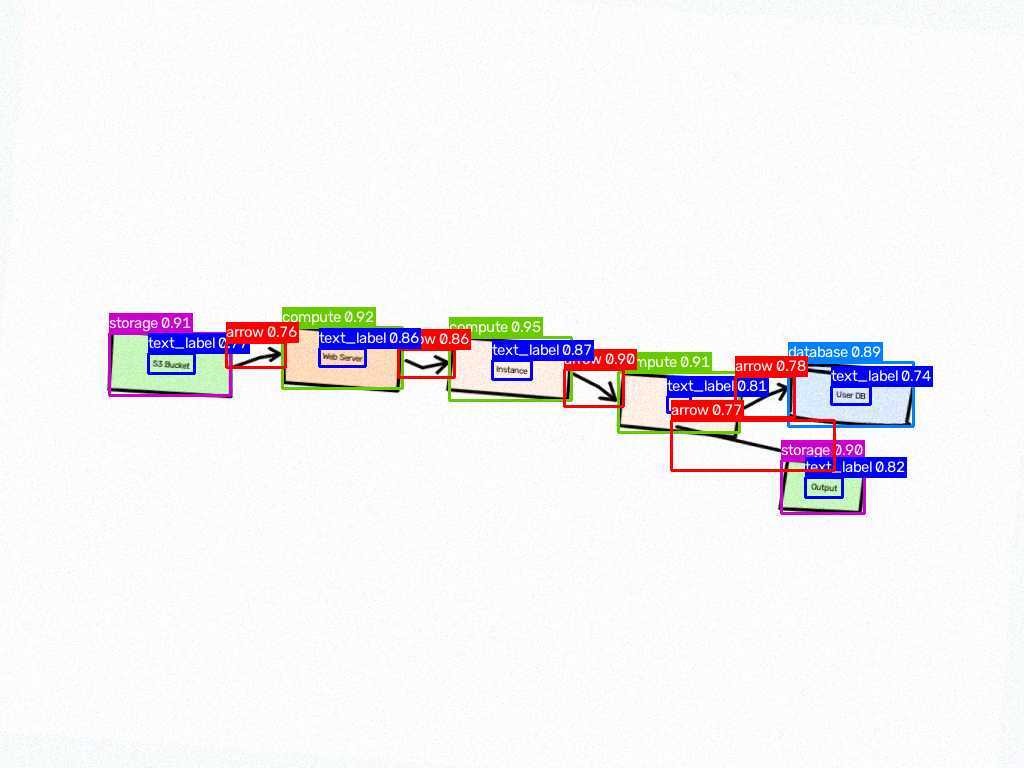

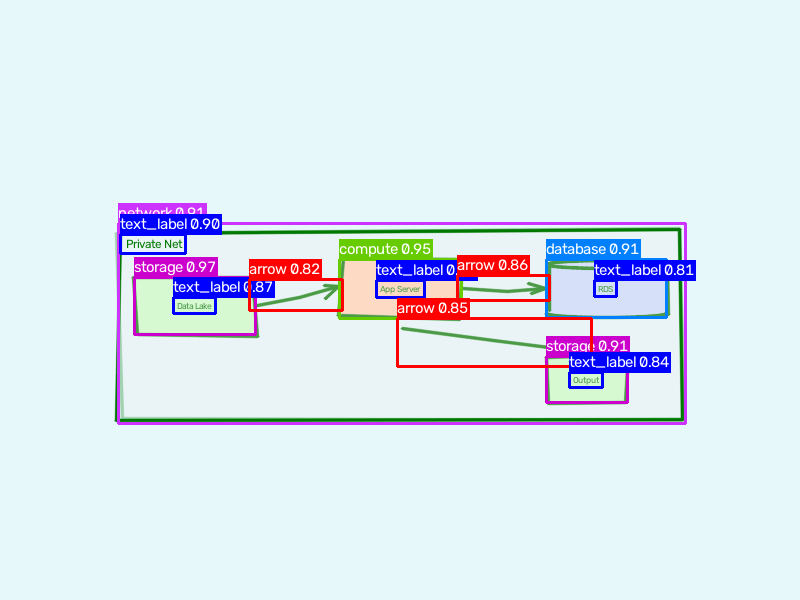

In [ ]:
from IPython.display import Image, display
import glob

print("=== Training Confusion Matrix ===")
display(Image(filename="/content/drive/MyDrive/diagram-to-infra-runs/train/confusion_matrix.png"))

print("=== Results Curves ===")
display(Image(filename="/content/drive/MyDrive/diagram-to-infra-runs/train/results.png"))

print("=== Sample Visual Predictions (from ml/eval_samples/) ===")
eval_images = glob.glob("ml/eval_samples/*.png")[:5]
for img_path in eval_images:
    display(Image(filename=img_path))

## Step 6: (Optional) Push Trained Weights to Hugging Face Hub

In [ ]:
from google.colab import userdata
from huggingface_hub import HfApi

HF_TOKEN = userdata.get('HF_TOKEN')  # set via Colab Secrets (key icon), not hardcoded
REPO_ID = "Parth2999/diagram-to-infra-yolov8n"
weights_path = os.path.join(run_dir, "weights", "best.pt")  # uses the dynamic run_dir from training

if HF_TOKEN:
    api = HfApi()
    api.create_repo(repo_id=REPO_ID, exist_ok=True, token=HF_TOKEN)
    api.upload_file(
        path_or_fileobj=weights_path,
        path_in_repo="best.pt",
        repo_id=REPO_ID,
        token=HF_TOKEN
    )
    print(f"Uploaded best.pt to https://huggingface.co/{REPO_ID}")
else:
    print(f"No HF_TOKEN provided. Weights are saved locally at {weights_path}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...uns/train/weights/best.pt:   9%|8         |  535kB / 6.25MB            

Uploaded best.pt to https://huggingface.co/Parth2999/diagram-to-infra-yolov8n


In [1]:
!pip install ultralytics huggingface_hub opencv-python-headless
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 7.3 MB/s eta 0:00:00


MessageError: Error: credential propagation was unsuccessful

In [ ]:
!git clone https://github.com/<your-username>/diagram-to-infra-code.git
%cd diagram-to-infra-code

In [1]:
!git clone https://github.com/Parths-29/diagram-to-infra-code.git
%cd diagram-to-infra-code
from huggingface_hub import hf_hub_download
weights_path = hf_hub_download(
    repo_id="Parth2999/diagram-to-infra-yolov8n",
    filename="best.pt",
    local_dir="ml/weights"
)
print(f"Weights downloaded: {weights_path}")

Cloning into 'diagram-to-infra-code'...
remote: Enumerating objects: 142, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 142 (delta 42), reused 106 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (142/142), 1.90 MiB | 5.85 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/diagram-to-infra-code


best.pt: reconstructing file:   0%|          |  0.00B / 6.25MB            

best.pt: downloading bytes:           |  0.00B            

Weights downloaded: /content/diagram-to-infra-code/ml/weights/best.pt


In [4]:
import os
os.makedirs("data/real_eval/images", exist_ok=True)

# Upload images via Colab's file picker
from google.colab import files
uploaded = files.upload()  # Select all 16 .jpeg files

# Move them into the right folder
for fname in uploaded:
    os.rename(fname, f"data/real_eval/images/{fname}")

# Verify
!ls data/real_eval/images/


Saving Media (1).jpeg to Media (1).jpeg
Saving Media (2).jpeg to Media (2).jpeg
Saving Media (3).jpeg to Media (3).jpeg
Saving Media (4).jpeg to Media (4).jpeg
Saving Media (5).jpeg to Media (5).jpeg
Saving Media (6).jpeg to Media (6).jpeg
Saving Media (7).jpeg to Media (7).jpeg
Saving Media (8).jpeg to Media (8).jpeg
Saving Media (9).jpeg to Media (9).jpeg
Saving Media (10).jpeg to Media (10).jpeg
Saving Media (11).jpeg to Media (11).jpeg
Saving Media (12).jpeg to Media (12).jpeg
Saving Media (13).jpeg to Media (13).jpeg
Saving Media (14).jpeg to Media (14).jpeg
Saving Media (15).jpeg to Media (15).jpeg
Saving Media.jpeg to Media.jpeg
'Media (10).jpeg'  'Media (14).jpeg'  'Media (3).jpeg'	'Media (7).jpeg'
'Media (11).jpeg'  'Media (15).jpeg'  'Media (4).jpeg'	'Media (8).jpeg'
'Media (12).jpeg'  'Media (1).jpeg'   'Media (5).jpeg'	'Media (9).jpeg'
'Media (13).jpeg'  'Media (2).jpeg'   'Media (6).jpeg'	 Media.jpeg


In [5]:
from ultralytics import YOLO

model = YOLO("ml/weights/best.pt")

results = model.predict(
    source="data/real_eval/images",
    conf=0.25,
    save=True,
    project="data/real_eval",
    name="results",
    exist_ok=True
)

print(f"✓ Processed {len(results)} images. Check data/real_eval/results/")



image 1/16 /content/diagram-to-infra-code/data/real_eval/images/Media (1).jpeg: 640x480 7 computes, 7 storages, 1 network, 5 arrows, 8 text_labels, 6.3ms
image 2/16 /content/diagram-to-infra-code/data/real_eval/images/Media (10).jpeg: 640x480 4 computes, 6 storages, 5 arrows, 3 text_labels, 6.7ms
image 3/16 /content/diagram-to-infra-code/data/real_eval/images/Media (11).jpeg: 640x480 12 computes, 1 database, 12 storages, 5 networks, 15 arrows, 17 text_labels, 6.1ms
image 4/16 /content/diagram-to-infra-code/data/real_eval/images/Media (12).jpeg: 640x480 3 computes, 6 storages, 1 network, 2 arrows, 10 text_labels, 6.0ms
image 5/16 /content/diagram-to-infra-code/data/real_eval/images/Media (13).jpeg: 640x480 7 computes, 2 databases, 5 storages, 1 network, 8 arrows, 9 text_labels, 6.4ms
image 6/16 /content/diagram-to-infra-code/data/real_eval/images/Media (14).jpeg: 640x480 8 computes, 18 storages, 10 arrows, 17 text_labels, 7.4ms
image 7/16 /content/diagram-to-infra-code/data/real_eval/i

Found 16 images

✓ Saved 16 annotated images

=== Detection Summary ===

📄 Media (1).jpeg: 28 detections
   → arrow: 0.93
   → arrow: 0.92
   → arrow: 0.91
   → storage: 0.87
   → compute: 0.81
   → arrow: 0.75
   → compute: 0.73
   → storage: 0.73
   → compute: 0.71
   → text_label: 0.67
   → text_label: 0.67
   → arrow: 0.64
   → storage: 0.63
   → network: 0.62
   → text_label: 0.60
   → text_label: 0.58
   → storage: 0.58
   → text_label: 0.48
   → compute: 0.45
   → text_label: 0.43
   → storage: 0.43
   → text_label: 0.43
   → compute: 0.43
   → storage: 0.40
   → storage: 0.39
   → compute: 0.31
   → compute: 0.30
   → text_label: 0.25

📄 Media (10).jpeg: 18 detections
   → storage: 0.79
   → compute: 0.77
   → arrow: 0.75
   → compute: 0.69
   → arrow: 0.66
   → storage: 0.59
   → arrow: 0.58
   → compute: 0.56
   → storage: 0.55
   → arrow: 0.54
   → compute: 0.49
   → arrow: 0.48
   → storage: 0.39
   → storage: 0.38
   → text_label: 0.36
   → text_label: 0.34
   → storage: 0

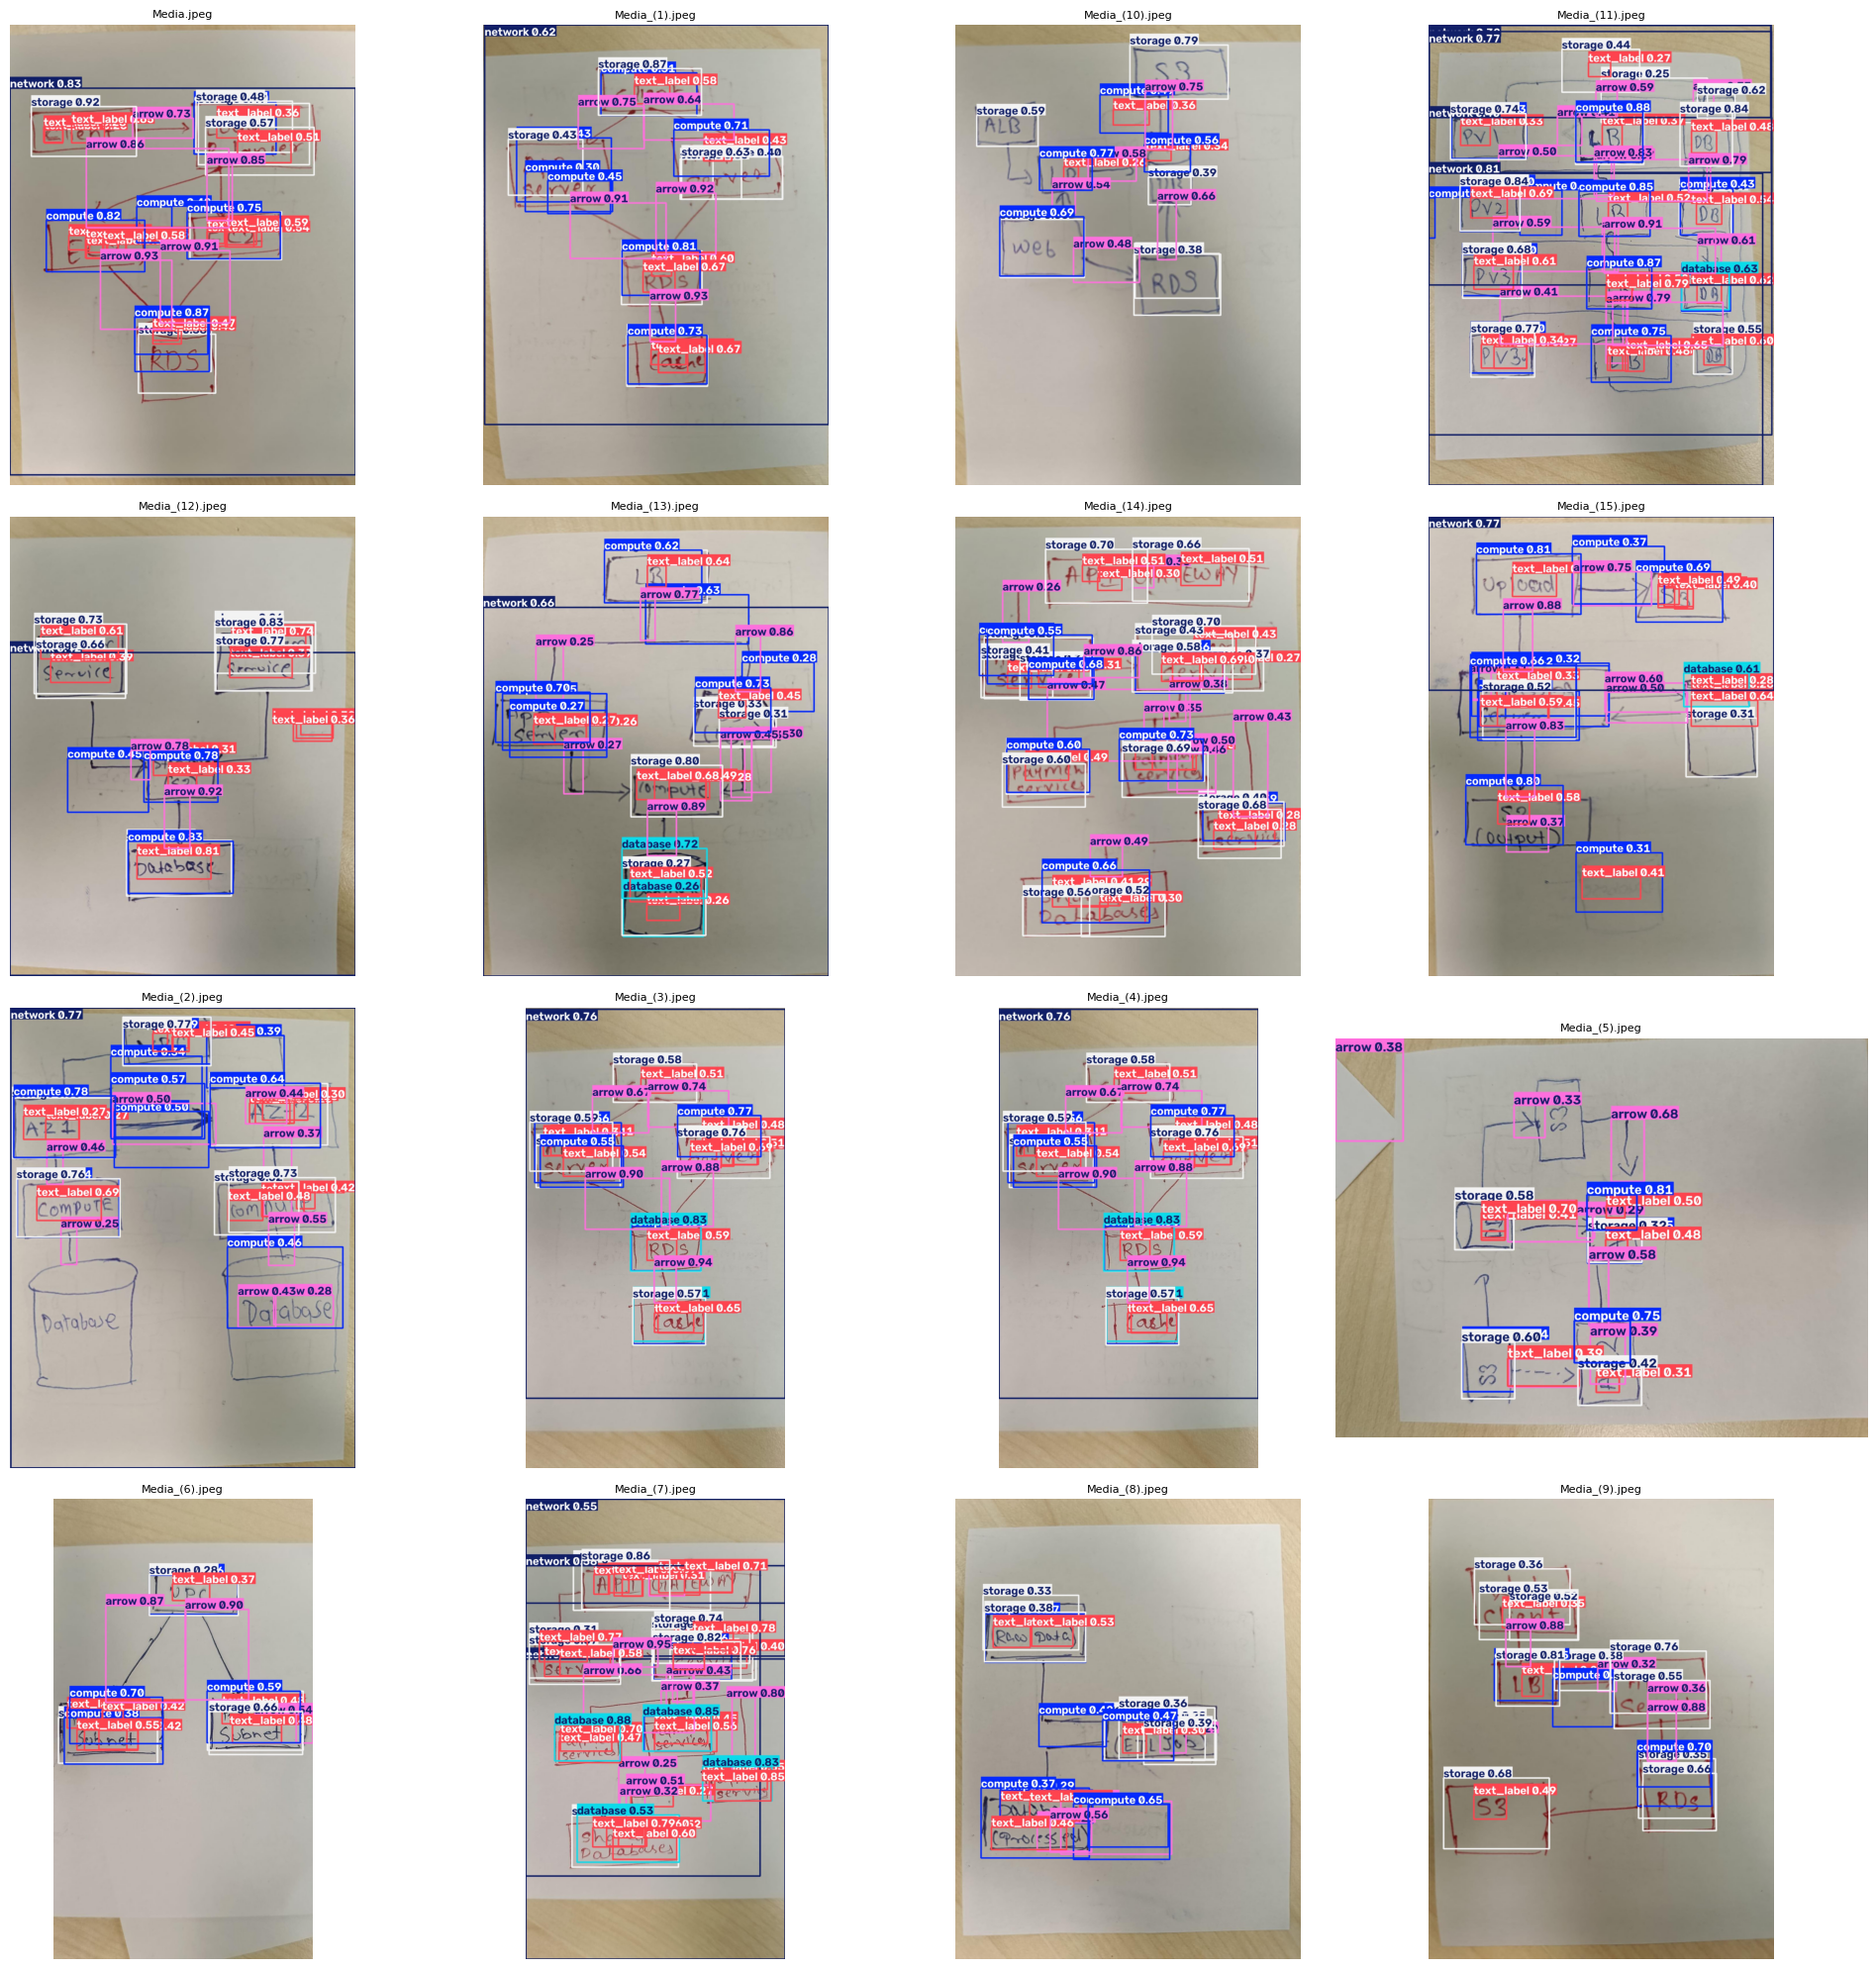

In [8]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import glob

# Load model
model = YOLO("ml/weights/best.pt")

# Create output dir
os.makedirs("data/real_eval/results", exist_ok=True)

# Get all images
images = sorted(glob.glob("data/real_eval/images/*.jpeg"))
print(f"Found {len(images)} images\n")

CLASS_NAMES = ["compute", "database", "storage", "load_balancer",
               "network", "arrow", "text_label"]

# Run inference one image at a time to avoid filename issues
all_results = []
for img_path in images:
    result = model.predict(source=img_path, conf=0.25, save=False, verbose=False)
    all_results.append((img_path, result[0]))

    # Save annotated image
    annotated = result[0].plot()
    out_name = os.path.basename(img_path).replace(" ", "_")
    cv2.imwrite(f"data/real_eval/results/{out_name}", annotated)

print(f"✓ Saved {len(all_results)} annotated images\n")

# Print detection summary
print("=== Detection Summary ===\n")
for img_path, r in all_results:
    fname = os.path.basename(img_path)
    boxes = r.boxes
    print(f"📄 {fname}: {len(boxes)} detections")
    for box in boxes:
        cls_id = int(box.cls[0].item())
        conf = float(box.conf[0].item())
        cls_name = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f"cls_{cls_id}"
        print(f"   → {cls_name}: {conf:.2f}")
    print()

# Display grid
result_files = sorted(glob.glob("data/real_eval/results/*.jpeg"))
cols = 4
rows = max(1, (len(result_files) + cols - 1) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten() if len(result_files) > 1 else [axes]

for i, img_path in enumerate(result_files):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(os.path.basename(img_path), fontsize=8)
    axes[i].axis("off")

for j in range(len(result_files), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("data/real_eval/results_grid.png", dpi=150)
plt.show()


In [9]:
import shutil
shutil.make_archive("real_eval_results", "zip", "data/real_eval/results")

from google.colab import files
files.download("real_eval_results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
files.download("data/real_eval/results_grid.png")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>